use k-means clustering to segment customers based behaviour and demographic data to enable marketing statagies

### Import Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [7]:
df = pd.read_excel('Retail_Sales_Dataset.xlsx')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2021-103800,2021-01-03,2021-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2021-112326,2021-01-04,2021-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2021-112326,2021-01-04,2021-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2021-112326,2021-01-04,2021-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2021-141817,2021-01-05,2021-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


### Basic Info and Data Cleaning

In [8]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2023-04-30 00:15:40.788699136,2023-05-03 23:20:43.790465024,228.225854,3.791838,0.155385,28.673417
min,1.000000,2021-01-03 00:00:00,2021-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2022-05-14 00:00:00,2022-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2023-06-25 00:00:00,2023-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2024-05-14 00:00:00,2024-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2024-12-30 00:00:00,2025-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


In [9]:

# Data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  object        
 2   Order Date      10194 non-null  datetime64[ns]
 3   Ship Date       10194 non-null  datetime64[ns]
 4   Ship Mode       10194 non-null  object        
 5   Customer ID     10194 non-null  object        
 6   Customer Name   10194 non-null  object        
 7   Segment         10194 non-null  object        
 8   Country/Region  10194 non-null  object        
 9   City            10194 non-null  object        
 10  State/Province  10194 non-null  object        
 11  Postal Code     10194 non-null  object        
 12  Region          10194 non-null  object        
 13  Product ID      10194 non-null  object        
 14  Category        10194 non-null  object        
 15  Su

In [10]:
# Missing Values
print("\nMissing values per column:")
print(df.isnull().sum())



Missing values per column:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


In [24]:
# Summary Statistics (Numerical)
print("\nSummary statistics for numeric columns:")
print(df[['Sales', 'Quantity', 'Discount', 'Profit']].describe())


Summary statistics for numeric columns:
              Sales      Quantity      Discount        Profit
count  10194.000000  10194.000000  10194.000000  10194.000000
mean     228.225854      3.791838      0.155385     28.673417
std      619.906839      2.228317      0.206249    232.465115
min        0.444000      1.000000      0.000000  -6599.978000
25%       17.220000      2.000000      0.000000      1.760800
50%       53.910000      3.000000      0.200000      8.690000
75%      209.500000      5.000000      0.200000     29.297925
max    22638.480000     14.000000      0.800000   8399.976000


## Visualization

### Count of Customers by Segment and Region

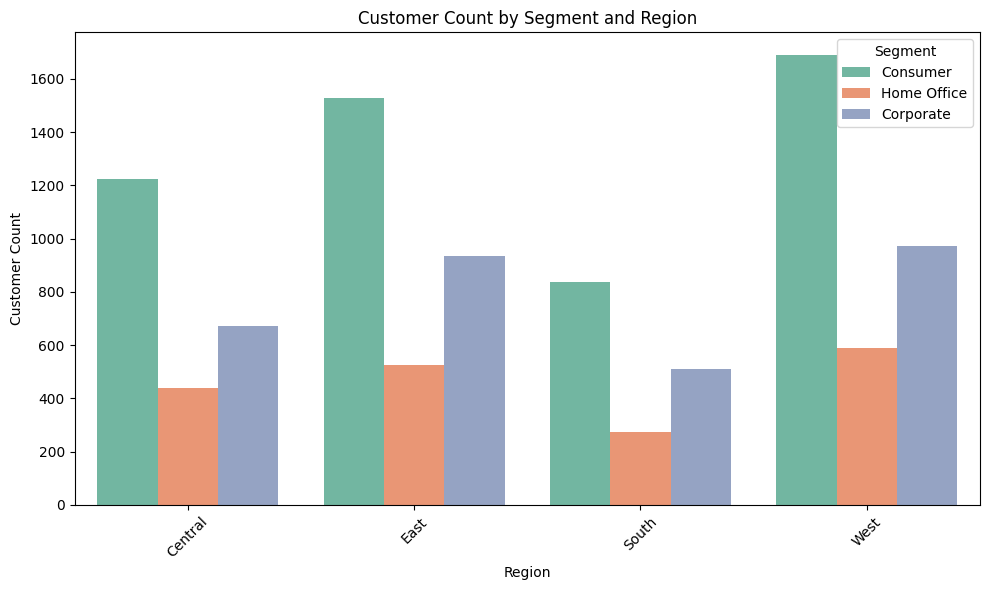

In [21]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Region', hue='Segment', palette='Set2')
plt.title('Customer Count by Segment and Region')
plt.xlabel('Region')
plt.ylabel('Customer Count')
plt.legend(title='Segment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Average Sales by Segment and Region (Heatmap)

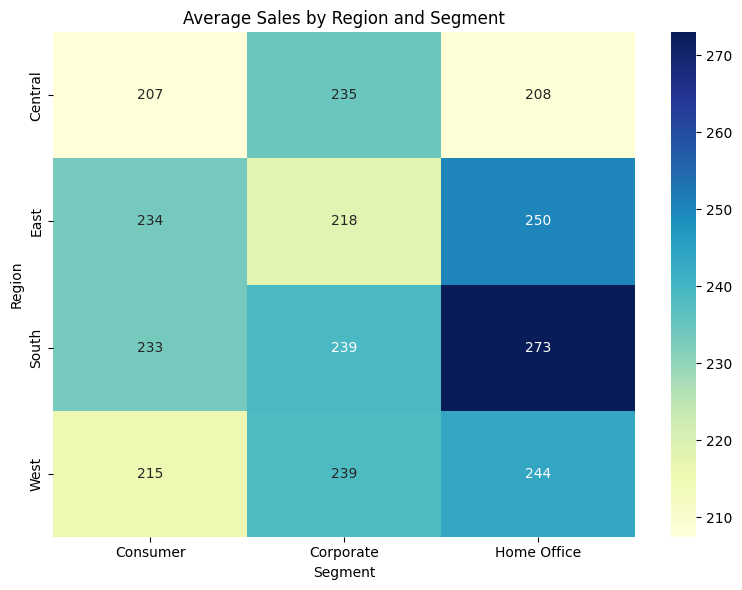

In [23]:
pivot_sales = df.pivot_table(values='Sales', index='Region', columns='Segment', aggfunc='mean')

plt.figure(figsize=(8,6))
sns.heatmap(pivot_sales, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Average Sales by Region and Segment')
plt.xlabel('Segment')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

## Feature Engineering for Clustering

In [11]:
# Group by Customer
customer_df = df.groupby(['Customer ID', 'Customer Name', 'Segment', 'Region']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Quantity': 'sum',
    'Discount': 'mean'
}).reset_index()


## Encode Categorical Variables

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
customer_df['Segment'] = le.fit_transform(customer_df['Segment'])
customer_df['Region'] = le.fit_transform(customer_df['Region'])

## Scalling Feature

In [13]:
features = ['Sales', 'Profit', 'Quantity', 'Discount', 'Segment', 'Region']
X = customer_df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Elbow Method to Find Optimal Clusters

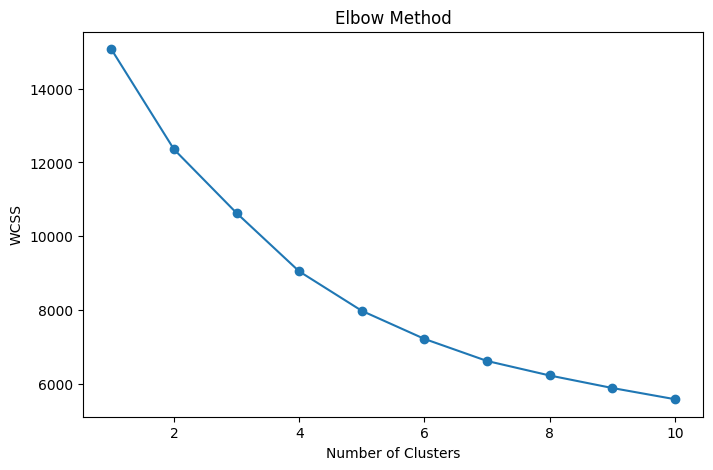

In [14]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [16]:

kmeans = KMeans(n_clusters=4, random_state=42)
customer_df['Cluster'] = kmeans.fit_predict(X_scaled)



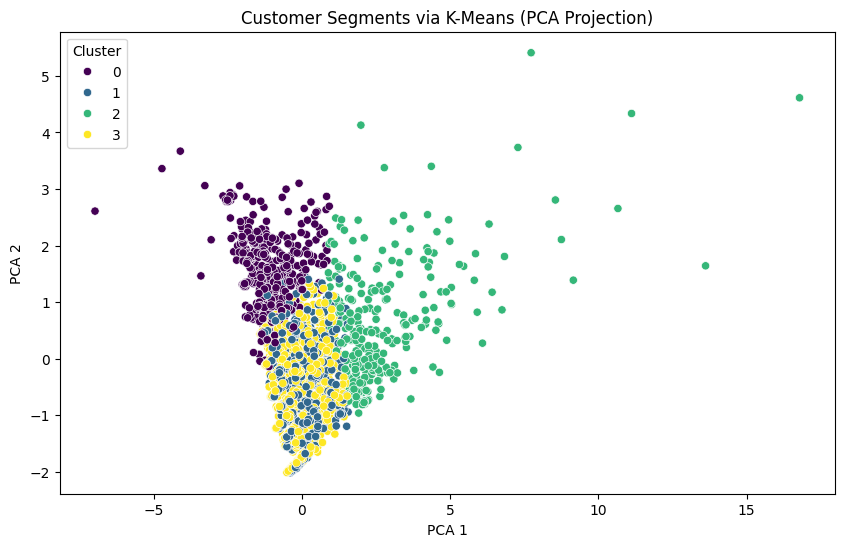

In [17]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(x=pca_components[:,0], y=pca_components[:,1],
                hue=customer_df['Cluster'], palette='viridis')
plt.title('Customer Segments via K-Means (PCA Projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()


'''
Cluster 0: High sales, low discounts → VIP customers

Cluster 1: Low sales, high discount usage → Bargain hunters

Cluster 2: Moderate sales and profits → Regular buyers

Cluster 3: Low everything → Infrequent customers '''

## Analyze Clusters

In [18]:
cluster_summary = customer_df.groupby('Cluster')[features].mean()
print(cluster_summary)


               Sales      Profit   Quantity  Discount   Segment    Region
Cluster                                                                  
0         666.297383 -167.456643  14.203426  0.419945  0.597430  0.524625
1         578.969012   86.452307  12.366748  0.100084  1.427873  1.696822
2        3523.201046  760.518336  37.052632  0.105167  0.722807  1.884211
3         570.769137   88.145811  12.043524  0.105049  0.000000  1.695329
